<a href="https://colab.research.google.com/github/bishakhamanna2-pixel/AgriculturePerformanceAnalysis/blob/main/project_VIOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#load the dataset
df = pd.read_csv("/content/seasonal_agriculture_performance_dataset.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


In [7]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [8]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [10]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3    

In [11]:
# check duplicates
duplicates = df.duplicated().sum()

print("Number of duplicate records:", duplicates)

Number of duplicate records: 0


In [12]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [13]:
#Unique Values
for column in df.columns:
    print("\nColumn:", column)
    print("Unique values:", df[column].nunique())


Column: Farm_ID
Unique values: 4000

Column: State
Unique values: 8

Column: District
Unique values: 10

Column: Crop
Unique values: 8

Column: Season
Unique values: 3

Column: Farm_Area_Hectares
Unique values: 1370

Column: Rainfall_mm
Unique values: 3256

Column: Avg_Temperature_C
Unique values: 204

Column: Humidity_pct
Unique values: 573

Column: Sunlight_Hours_Day
Unique values: 71

Column: Soil_pH
Unique values: 313

Column: Soil_Moisture_pct
Unique values: 343

Column: Nitrogen_kg_ha
Unique values: 1229

Column: Phosphorus_kg_ha
Unique values: 760

Column: Potassium_kg_ha
Unique values: 1137

Column: Irrigation_Method
Unique values: 4

Column: Fertilizer_kg_ha
Unique values: 1881

Column: Pesticide_Litre_ha
Unique values: 851

Column: Seed_Quality_Score
Unique values: 36

Column: Yield_Tonnes_Ha
Unique values: 738

Column: Production_Tonnes
Unique values: 2528

Column: Market_Price_INR_Tonne
Unique values: 3760

Column: Total_Cost_INR
Unique values: 3995

Column: Revenue_INR
Un

In [14]:
# Numerical columns (missing value handling)
numerical_columns = df.select_dtypes(include=np.number).columns

for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

In [15]:
# Categorical columns
categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

In [16]:
# Removes Extra Spaces from Text
for column in categorical_columns:
    df[column] = df[column].astype(str).str.strip()

In [17]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Farm_ID                          0
State                            0
District                         0
Crop                             0
Season                           0
Farm_Area_Hectares               0
Rainfall_mm                      0
Avg_Temperature_C                0
Humidity_pct                     0
Sunlight_Hours_Day               0
Soil_pH                          0
Soil_Moisture_pct                0
Nitrogen_kg_ha                   0
Phosphorus_kg_ha                 0
Potassium_kg_ha                  0
Irrigation_Method                0
Fertilizer_kg_ha                 0
Pesticide_Litre_ha               0
Seed_Quality_Score               0
Yield_Tonnes_Ha                  0
Production_Tonnes                0
Market_Price_INR_Tonne           0
Total_Cost_INR                   0
Revenue_INR                      0
Profit_INR                       0
Water_Used_m3                    0
Water_Efficiency_t_per_1000m3    0
Disease_Pest_Risk_pct   

In [18]:
print(df['Season'].unique())

['Kharif' 'Rabi' 'Zaid']


In [19]:
df.columns.tolist()

['Farm_ID',
 'State',
 'District',
 'Crop',
 'Season',
 'Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Irrigation_Method',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct']

In [20]:
# Compare agricultural performance across seasons

season_performance = df.groupby('Season')[[
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Profit_INR'
]].mean().round(2)

print(season_performance)

        Yield_Tonnes_Ha  Production_Tonnes  Profit_INR
Season                                                
Kharif             5.63              46.31   178914.65
Rabi               5.04              41.49    87689.47
Zaid               4.64              38.89   -24804.82


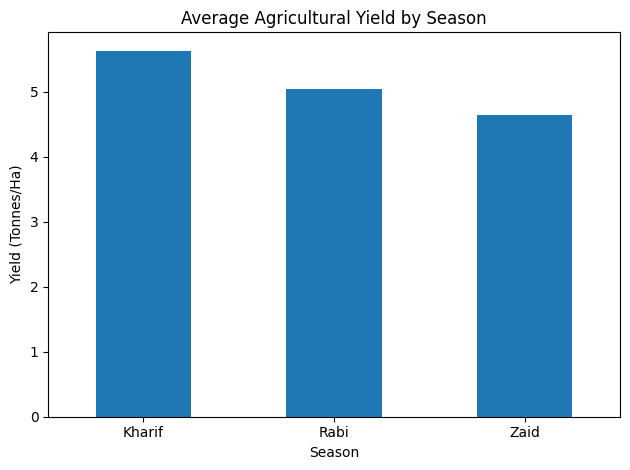

In [21]:
season_performance['Yield_Tonnes_Ha'].plot(
    kind='bar',
    title='Average Agricultural Yield by Season',
    xlabel='Season',
    ylabel='Yield (Tonnes/Ha)'
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:
season_pattern = df.groupby('Season')[[
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Profit_INR'
]].mean().round(2)

print(season_pattern)

        Yield_Tonnes_Ha  Production_Tonnes  Profit_INR
Season                                                
Kharif             5.63              46.31   178914.65
Rabi               5.04              41.49    87689.47
Zaid               4.64              38.89   -24804.82


In [23]:
season_conditions = df.groupby('Season')[[
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Soil_Moisture_pct',
    'Yield_Tonnes_Ha'
]].mean().round(2)

print(season_conditions)

        Rainfall_mm  Avg_Temperature_C  Soil_Moisture_pct  Yield_Tonnes_Ha
Season                                                                    
Kharif       849.20              28.45              31.15             5.63
Rabi         437.62              23.49              24.07             5.04
Zaid         304.65              31.04              19.28             4.64


In [24]:
season_crop = df.groupby(['Season', 'Crop'])['Yield_Tonnes_Ha'].mean().round(2)

print(season_crop)

Season  Crop     
Kharif  Chilli        1.73
        Cotton        1.37
        Groundnut     1.48
        Maize         2.97
        Pulses        1.04
        Rice          2.70
        Sugarcane    53.46
        Wheat         2.25
Rabi    Chilli        1.47
        Cotton        1.20
        Groundnut     1.23
        Maize         2.60
        Pulses        0.88
        Rice          2.32
        Sugarcane    43.29
        Wheat         2.06
Zaid    Chilli        1.20
        Cotton        0.96
        Groundnut     1.04
        Maize         2.29
        Pulses        0.67
        Rice          1.90
        Sugarcane    38.42
        Wheat         1.75
Name: Yield_Tonnes_Ha, dtype: float64


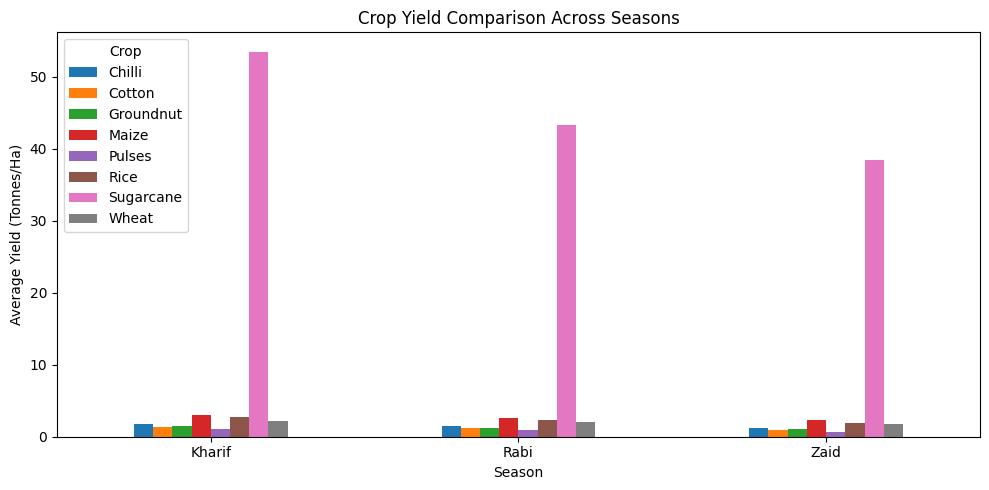

In [25]:
season_crop.unstack().plot(kind='bar', figsize=(10, 5))

plt.title('Crop Yield Comparison Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [26]:
# Compare yield and profit across seasons
season_analysis = df.groupby('Season')[[
    'Yield_Tonnes_Ha',
    'Profit_INR'
]].mean().round(2)

print(season_analysis)


        Yield_Tonnes_Ha  Profit_INR
Season                             
Kharif             5.63   178914.65
Rabi               5.04    87689.47
Zaid               4.64   -24804.82


In [27]:
# Find farms with negative profit
unusual = df[df['Profit_INR'] < 0]

print(unusual[['Season', 'Crop', 'Yield_Tonnes_Ha', 'Profit_INR']].head())

   Season    Crop  Yield_Tonnes_Ha  Profit_INR
0  Kharif   Wheat             2.46      -11852
1  Kharif   Maize             0.30     -451950
2    Rabi  Pulses             0.52     -124744
3  Kharif    Rice             1.84      -95704
4    Zaid   Maize             2.21     -144352


In [28]:
# Statistical summary by season
stats = df.groupby('Season')[[
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Profit_INR'
]].agg(['mean', 'std']).round(2)

print(stats)

       Yield_Tonnes_Ha        Production_Tonnes        Profit_INR           
                  mean    std              mean    std       mean        std
Season                                                                      
Kharif            5.63  14.39             46.31  135.7  178914.65  611549.78
Rabi              5.04  12.75             41.49  121.9   87689.47  489901.25
Zaid              4.64  11.27             38.89  112.0  -24804.82  436356.75


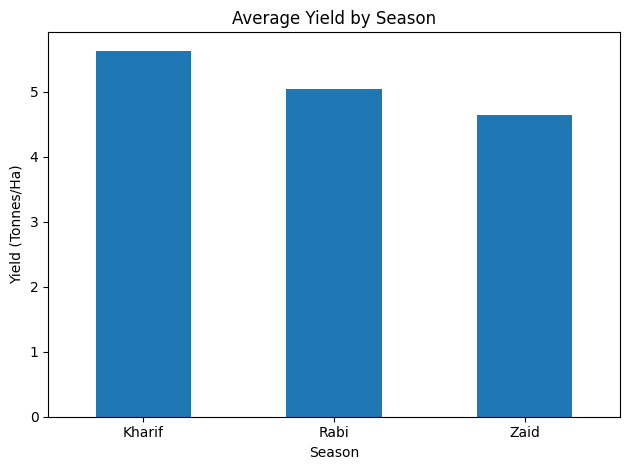

In [29]:
# Average yield by season
df.groupby('Season')['Yield_Tonnes_Ha'].mean().plot(
    kind='bar',
    title='Average Yield by Season',
    xlabel='Season',
    ylabel='Yield (Tonnes/Ha)'
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [30]:
# Seasonal performance summary
findings = df.groupby('Season')[[
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Profit_INR'
]].mean().round(2)

print(findings)

        Yield_Tonnes_Ha  Production_Tonnes  Profit_INR
Season                                                
Kharif             5.63              46.31   178914.65
Rabi               5.04              41.49    87689.47
Zaid               4.64              38.89   -24804.82


In [31]:
# Seasonal performance summary
summary = df.groupby('Season')[[
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Profit_INR'
]].mean().round(2)

print("Seasonal Performance:")
print(summary)

# Find best and lowest performing seasons
best_yield = summary['Yield_Tonnes_Ha'].idxmax()
lowest_yield = summary['Yield_Tonnes_Ha'].idxmin()

best_profit = summary['Profit_INR'].idxmax()
lowest_profit = summary['Profit_INR'].idxmin()

print("\nConclusion:")
print("Highest yield season:", best_yield)
print("Lowest yield season:", lowest_yield)
print("Highest profit season:", best_profit)
print("Lowest profit season:", lowest_profit)

Seasonal Performance:
        Yield_Tonnes_Ha  Production_Tonnes  Profit_INR
Season                                                
Kharif             5.63              46.31   178914.65
Rabi               5.04              41.49    87689.47
Zaid               4.64              38.89   -24804.82

Conclusion:
Highest yield season: Kharif
Lowest yield season: Zaid
Highest profit season: Kharif
Lowest profit season: Zaid


In [32]:
print("\nRecommendations:")

print(f"- Focus on farming practices that support the performance of {best_yield}.")
print(f"- Investigate the factors responsible for lower performance in {lowest_yield}.")
print(f"- Optimize water, fertilizer, and other resources according to seasonal requirements.")
print(f"- Use seasonal performance data for better planning and resource allocation.")


Recommendations:
- Focus on farming practices that support the performance of Kharif.
- Investigate the factors responsible for lower performance in Zaid.
- Optimize water, fertilizer, and other resources according to seasonal requirements.
- Use seasonal performance data for better planning and resource allocation.
